# Fairness Analysis — Medical Bios Classification
## Étape 1 : Modèle de base biaisé (DistilBERT + Régression Logistique)

**Objectif** : Classifier les professions médicales à partir de biographies textuelles,  
puis analyser les biais de prédiction liés au genre (Male/Female).

**Pipeline** :
1. Import des fichiers  
2. Preprocessing  
3. Entraînement  
4. Résultats globaux, par profession et par genre

> ⚠️ Ce modèle est intentionnellement entraîné sur le texte brut (`full_text`) qui contient  
> des marqueurs de genre (pronoms he/she, Dr./Mrs., etc.). C'est le **modèle biaisé de référence**.  
> Les étapes suivantes chercheront à réduire ce biais.


In [ ]:
# ── Installation des dépendances ─────────────────────────────────────
# À exécuter en premier sur Google Colab (déjà présent sur la plupart des runtimes,
# mais cette cellule garantit les bonnes versions)
!pip install -q transformers scikit-learn datasets


In [ ]:
import os
# ── Google Drive (pour persister les embeddings entre les sessions) ──
from google.colab import drive
drive.mount("/content/drive")

DRIVE_DIR = "/content/drive/MyDrive/fairness_nlp"
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f"📁 Dossier Drive : {DRIVE_DIR}")


Mounted at /content/drive
📁 Dossier Drive : /content/drive/MyDrive/fairness_nlp


---
## Section 1 — Import des librairies & configuration


In [ ]:
import os
import json
import pickle
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
from transformers import AutoTokenizer, AutoModel

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# ── Reproductibilité ─────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ───────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"PyTorch : {torch.__version__}")


Device : cuda
PyTorch : 2.10.0+cu128


---
## Section 2 — Import des fichiers (dataset Medical Bios)

Les fichiers `train.jsonl`, `validation.jsonl` et `test.jsonl` sont déjà disponibles  
dans le répertoire de travail. Chaque ligne est un objet JSON avec les champs :  
`full_text`, `text`, `title` (profession), `gender`, `date`.


In [ ]:
import zipfile

# ── Téléchargement du dataset depuis HuggingFace ────────────────────
DATA_DIR  = "/content/medical_bios"
ZIP_PATH  = "/content/bios.zip"
HF_URL    = "https://huggingface.co/datasets/coastalcph/medical-bios/resolve/main/bios.zip"

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(os.path.join(DATA_DIR, "train.jsonl")):
    print("⬇️  Téléchargement du dataset...")
    !wget -q -O {ZIP_PATH} {HF_URL}
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(DATA_DIR)
    print("✅ Dataset extrait dans", DATA_DIR)
else:
    print("📂 Dataset déjà présent dans", DATA_DIR)

# ── Chargement des fichiers JSONL ────────────────────────────────────
def load_jsonl(path: str) -> list[dict]:
    """Charge un fichier JSONL et retourne une liste de dictionnaires."""
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

train_raw = load_jsonl(os.path.join(DATA_DIR, "train.jsonl"))
val_raw   = load_jsonl(os.path.join(DATA_DIR, "validation.jsonl"))
test_raw  = load_jsonl(os.path.join(DATA_DIR, "test.jsonl"))

print(f"Train      : {len(train_raw):>6} exemples")
print(f"Validation : {len(val_raw):>6} exemples")
print(f"Test       : {len(test_raw):>6} exemples")
print(f"\nExemple :\n{json.dumps(train_raw[0], indent=2, ensure_ascii=False)[:400]}")


⬇️  Téléchargement du dataset...
✅ Dataset extrait dans /content/medical_bios
Train      :   8000 exemples
Validation :   1000 exemples
Test       :   1000 exemples

Exemple :
{
  "full_text": "Dr. Vikram Prasad is an experienced Dentist in Sowkhya Ayurveda Speciality Clinic, Chennai. He has been a practicing Dentist for 20 years. He has done BDS . He is currently associated with Sree Sai Dental Clinic in Sowkhya Ayurveda Speciality Clinic, Chennai. Book an appointment online with Dr. Vikram Prasad and consult privately on Lybrate.com.",
  "text": "He has been a practic


---
## Section 3 — Preprocessing & Encodage des labels

**Champ d'entrée** : `full_text` (contient prénom + genre signalé implicitement via les pronoms).  
C'est ce choix qui introduit le biais initial — nous le conservons volontairement.


In [ ]:
# ── DataFrames ───────────────────────────────────────────────────────
df_train = pd.DataFrame(train_raw)
df_val   = pd.DataFrame(val_raw)
df_test  = pd.DataFrame(test_raw)

# ── Encodage des labels (fit global train+val+test) ───────────────────
le = LabelEncoder()
all_titles = (
    df_train["title"].tolist()
    + df_val["title"].tolist()
    + df_test["title"].tolist()
)
le.fit(all_titles)

df_train["label"] = le.transform(df_train["title"])
df_val["label"]   = le.transform(df_val["title"])
df_test["label"]  = le.transform(df_test["title"])

CLASS_NAMES = le.classes_
N_CLASSES   = len(CLASS_NAMES)

print(f"Professions ({N_CLASSES}) : {list(CLASS_NAMES)}")
print()

# ── Distribution genre × profession ─────────────────────────────────
pivot = df_train.groupby(["title", "gender"]).size().unstack(fill_value=0)
pivot["Total"] = pivot.sum(axis=1)
print("Distribution genre × profession (train) :")
print(pivot.to_string())
print()

# ── Distribution globale du genre ────────────────────────────────────
print("Distribution globale du genre (train) :")
print(df_train["gender"].value_counts(normalize=True).mul(100).round(1).to_string())


Professions (5) : [np.str_('dentist'), np.str_('nurse'), np.str_('physician'), np.str_('psychologist'), np.str_('surgeon')]

Distribution genre × profession (train) :
gender        Female  Male  Total
title                            
dentist          537   996   1533
nurse           1486   152   1638
physician        699   650   1349
psychologist    1378   822   2200
surgeon          190  1090   1280

Distribution globale du genre (train) :
gender
Female    53.6
Male      46.4


### 3.1 — Fonction de preprocessing minimal (modèle biaisé)

Preprocessing **intentionnellement minimal** : on conserve **tous** les tokens du texte original —
pronoms genrés (`he`/`she`/`his`/`her`), titres (`Mr`/`Mrs`/`Dr`), prénoms, stopwords…
Seuls les **mots correspondant aux labels de profession** sont supprimés (éviter la fuite d'information directe).

> ⚠️ Ce choix maximalise le biais de genre — c'est voulu pour servir de référence contrastive avec v2.


In [ ]:
import re
import string

# ── Mots-labels à supprimer (fuite d'info directe) ───────────────────
# On tokenise chaque nom de classe pour gérer les noms composés
LABEL_WORDS = set()
for cls in CLASS_NAMES:
    for token in re.split(r"[\s\-_/]", cls.lower()):
        if token:
            LABEL_WORDS.add(token)

print(f"Mots-labels supprimés : {sorted(LABEL_WORDS)}")

# ── Fonction de preprocessing ────────────────────────────────────────
def preprocess(text: str) -> str:
    """
    Preprocessing minimal (modèle biaisé) :
      1. Mise en minuscules
      2. Suppression de la ponctuation
      3. Suppression des mots-labels de profession uniquement
    Tout le reste est conservé : pronoms genrés, titres, prénoms, stopwords…
    """
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = [t for t in text.split() if t not in LABEL_WORDS]
    return " ".join(tokens)

# ── Application sur les trois splits ────────────────────────────────
df_train["text_clean"] = df_train["full_text"].map(preprocess)
df_val["text_clean"]   = df_val["full_text"].map(preprocess)
df_test["text_clean"]  = df_test["full_text"].map(preprocess)

# ── Vérification sur un exemple ──────────────────────────────────────
idx = 0
print(f"\n--- Texte original ---\n{df_train['full_text'].iloc[idx][:300]}")
print(f"\n--- Texte nettoyé ---\n{df_train['text_clean'].iloc[idx][:300]}")
print(f"\nLongueur moyenne (tokens) avant : "
      f"{df_train['full_text'].str.split().str.len().mean():.0f}")
print(f"Longueur moyenne (tokens) après : "
      f"{df_train['text_clean'].str.split().str.len().mean():.0f}")


Mots-labels supprimés : ['dentist', 'nurse', 'physician', 'psychologist', 'surgeon']

--- Texte original ---
Dr. Vikram Prasad is an experienced Dentist in Sowkhya Ayurveda Speciality Clinic, Chennai. He has been a practicing Dentist for 20 years. He has done BDS . He is currently associated with Sree Sai Dental Clinic in Sowkhya Ayurveda Speciality Clinic, Chennai. Book an appointment online with Dr. Vikr

--- Texte nettoyé ---
dr vikram prasad is an experienced in sowkhya ayurveda speciality clinic chennai he has been a practicing for 20 years he has done bds he is currently associated with sree sai dental clinic in sowkhya ayurveda speciality clinic chennai book an appointment online with dr vikram prasad and consult pri

Longueur moyenne (tokens) avant : 74
Longueur moyenne (tokens) après : 72


---
## Section 4 — Entraînement (DistilBERT → embeddings + Régression Logistique)

### 4.1 — Extraction des embeddings DistilBERT


In [ ]:
DISTILBERT_MODEL = "distilbert-base-uncased"
BATCH_SIZE       = 32
MAX_LENGTH       = 512

# ── Cache des embeddings dans Drive (survit aux redémarrages du runtime) ──
EMB_DIR = os.path.join(DRIVE_DIR, "embeddings_baseline")
os.makedirs(EMB_DIR, exist_ok=True)
print(f"📁 Cache embeddings : {EMB_DIR}")

print(f"Modèle : {DISTILBERT_MODEL}")
print(f"Device : {device}")
print("Chargement du tokenizer et du modèle DistilBERT...")

tokenizer = AutoTokenizer.from_pretrained(DISTILBERT_MODEL)
model     = AutoModel.from_pretrained(DISTILBERT_MODEL).to(device)
model.eval()

print("✅ DistilBERT chargé.")
print(f"   Hidden size    : {model.config.hidden_size}")
print(f"   Layers         : {model.config.num_hidden_layers}")
print(f"   Attention heads: {model.config.num_attention_heads}")


📁 Cache embeddings : /content/drive/MyDrive/fairness_nlp/embeddings_baseline
Modèle : distilbert-base-uncased
Device : cuda
Chargement du tokenizer et du modèle DistilBERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ DistilBERT chargé.
   Hidden size    : 768
   Layers         : 6
   Attention heads: 12


In [ ]:
def extract_embeddings(texts: list[str], batch_size: int = 32, max_length: int = 512) -> np.ndarray:
    """
    Extrait le vecteur [CLS] du dernier hidden state de DistilBERT pour chaque texte.
    Traitement par batches pour éviter les OOM.
    """
    model.eval()
    all_embeddings = []
    n = len(texts)
    for start in range(0, n, batch_size):
        batch = texts[start : start + batch_size]
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        ).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            cls_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_emb)
        if (start // batch_size + 1) % 20 == 0:
            print(f"  {start + len(batch)}/{n} textes traités...")
    return np.concatenate(all_embeddings, axis=0)


# ── Extraction (ou chargement depuis le cache) ─────────────────────
# Texte d'entrée : text_clean (full_text préprocessé)
CACHE = {
    "X_train": os.path.join(EMB_DIR, "X_train.npy"),
    "X_val":   os.path.join(EMB_DIR, "X_val.npy"),
}

if all(os.path.exists(p) for p in CACHE.values()):
    print("📂 Chargement des embeddings depuis le cache...")
    X_train = np.load(CACHE["X_train"])
    X_val   = np.load(CACHE["X_val"])
else:
    print("🔄 Extraction des embeddings train (text_clean)...")
    t0 = time.time()
    X_train = extract_embeddings(df_train["text_clean"].tolist(), BATCH_SIZE, MAX_LENGTH)
    print(f"   ✅ train : {X_train.shape}  ({time.time()-t0:.0f}s)")

    print("🔄 Extraction des embeddings validation (text_clean)...")
    t1 = time.time()
    X_val = extract_embeddings(df_val["text_clean"].tolist(), BATCH_SIZE, MAX_LENGTH)
    print(f"   ✅ val   : {X_val.shape}  ({time.time()-t1:.0f}s)")

    np.save(CACHE["X_train"], X_train)
    np.save(CACHE["X_val"],   X_val)
    print("💾 Embeddings sauvegardés dans", EMB_DIR)

y_train = df_train["label"].values
y_val   = df_val["label"].values
val_genders = df_val["gender"].values

print(f"\nShapes finaux — X_train: {X_train.shape}, X_val: {X_val.shape}")


🔄 Extraction des embeddings train (text_clean)...
  640/8000 textes traités...
  1280/8000 textes traités...
  1920/8000 textes traités...
  2560/8000 textes traités...
  3200/8000 textes traités...
  3840/8000 textes traités...
  4480/8000 textes traités...
  5120/8000 textes traités...
  5760/8000 textes traités...
  6400/8000 textes traités...
  7040/8000 textes traités...
  7680/8000 textes traités...
   ✅ train : (8000, 768)  (34s)
🔄 Extraction des embeddings validation (text_clean)...
  640/1000 textes traités...
   ✅ val   : (1000, 768)  (4s)
💾 Embeddings sauvegardés dans /content/drive/MyDrive/fairness_nlp/embeddings_baseline

Shapes finaux — X_train: (8000, 768), X_val: (1000, 768)


### 4.2 — Entraînement de la Régression Logistique


In [ ]:
clf = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED, n_jobs=-1)

print("🔄 Entraînement de la Régression Logistique...")
t0 = time.time()
clf.fit(X_train, y_train)
print(f"✅ Entraînement terminé en {time.time()-t0:.1f}s")

# ── Prédictions ────────────────────────────────────────────────────
y_pred_train = clf.predict(X_train)
y_pred_val   = clf.predict(X_val)


🔄 Entraînement de la Régression Logistique...
✅ Entraînement terminé en 12.7s


---
## Section 5 — Résultats globaux (Accuracy & F1)


In [ ]:
acc_train    = accuracy_score(y_train, y_pred_train)
acc_val      = accuracy_score(y_val,   y_pred_val)
f1_macro     = f1_score(y_val, y_pred_val, average="macro")
recall_macro = recall_score(y_val, y_pred_val, average="macro")

print("=" * 50)
print("  RÉSULTATS GLOBAUX — VALIDATION")
print("=" * 50)
print(f"  Accuracy train      : {acc_train:.4f}")
print(f"  Accuracy validation : {acc_val:.4f}")
print(f"  F1 macro            : {f1_macro:.4f}")
print(f"  Recall macro        : {recall_macro:.4f}")
print("=" * 50)


  RÉSULTATS GLOBAUX — VALIDATION
  Accuracy train      : 0.9387
  Accuracy validation : 0.8970
  F1 macro            : 0.8908
  Recall macro        : 0.8869


---
## Section 6 — Résultats par profession

F1-score par classe sur le set de validation.


Classification report (validation) :
              precision    recall  f1-score   support

     dentist     0.9467    0.9302    0.9384       172
       nurse     0.9028    0.9028    0.9028       216
   physician     0.8471    0.8372    0.8421       172
psychologist     0.9000    0.9490    0.9238       294
     surgeon     0.8815    0.8151    0.8470       146

    accuracy                         0.8970      1000
   macro avg     0.8956    0.8869    0.8908      1000
weighted avg     0.8968    0.8970    0.8965      1000



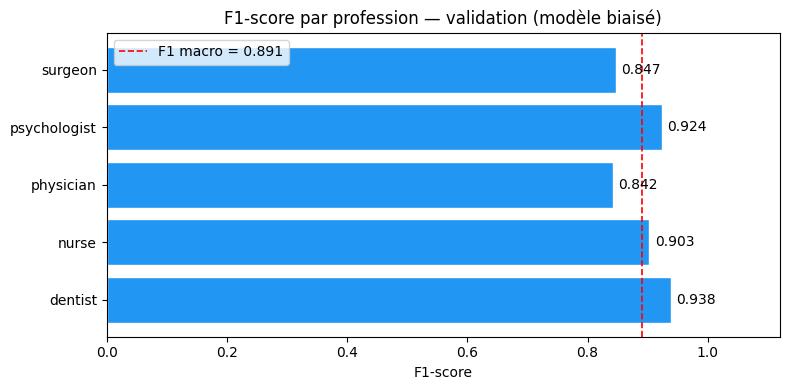

✅ Figure sauvegardée : results_by_profession.png


In [ ]:
print("Classification report (validation) :")
print(classification_report(y_val, y_pred_val, target_names=CLASS_NAMES, digits=4))

# ── F1 par profession ────────────────────────────────────────────────
f1_per_class = f1_score(y_val, y_pred_val, average=None, labels=range(N_CLASSES))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(CLASS_NAMES, f1_per_class, color="#2196F3", edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=4)
ax.set_xlim(0, 1.12)
ax.set_xlabel("F1-score")
ax.set_title("F1-score par profession — validation (modèle biaisé)")
ax.axvline(f1_macro, color="red", linestyle="--", linewidth=1.2, label=f"F1 macro = {f1_macro:.3f}")
ax.legend()
plt.tight_layout()
plt.savefig("results_by_profession.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure sauvegardée : results_by_profession.png")


---
## Section 7 — Analyse de fairness par genre

On divise les prédictions selon le genre et on compare deux métriques complémentaires :

- **F1-score par profession** — mesure la performance globale (précision + rappel)
- **Recall par profession** — critère *Equal Opportunity* (Hardt et al., 2016) :  
  *"Parmi toutes les personnes qui exercent réellement une profession, combien le modèle reconnaît-il correctement ?"*  
  C'est la métrique centrale pour la fairness : un recall plus faible sur un groupe signifie que le modèle les pénalise.

L'**écart de genre** (gender gap) est exprimé de façon **directionnelle** (Hommes − Femmes) :  
`+` = avantage Hommes, `−` = avantage Femmes.


In [ ]:
gender_stats = {}

for gender in ["Male", "Female"]:
    mask     = val_genders == gender
    y_true_g = y_val[mask]
    y_pred_g = y_pred_val[mask]

    gender_stats[gender] = {
        "n"               : mask.sum(),
        "acc"             : accuracy_score(y_true_g, y_pred_g),
        "f1_macro"        : f1_score(y_true_g, y_pred_g, average="macro",    zero_division=0),
        "recall_macro"    : recall_score(y_true_g, y_pred_g, average="macro", zero_division=0),
        "f1_per_class"    : f1_score(y_true_g, y_pred_g, average=None,
                                     labels=range(N_CLASSES), zero_division=0),
        "recall_per_class": recall_score(y_true_g, y_pred_g, average=None,
                                         labels=range(N_CLASSES), zero_division=0),
    }

print("=" * 65)
print("  RÉSULTATS PAR GENRE — VALIDATION")
print("=" * 65)
for g, s in gender_stats.items():
    label = "Hommes" if g == "Male" else "Femmes"
    print(f"\n  {label} (n={s['n']})")
    print(f"    Accuracy     : {s['acc']:.4f}")
    print(f"    F1 macro     : {s['f1_macro']:.4f}")
    print(f"    Recall macro : {s['recall_macro']:.4f}  ← Equal Opportunity")
    print(f"\n    {'Profession':<15}   {'F1':>6}   {'Recall':>6}")
    print(f"    {'-'*37}")
    for i, cls in enumerate(CLASS_NAMES):
        print(f"    {cls:<15} : {s['f1_per_class'][i]:>6.4f}   {s['recall_per_class'][i]:>6.4f}")

print()

# ── Gaps directionnels par profession (Hommes − Femmes) ──────────────
# + = avantage Hommes,  − = avantage Femmes
f1_male    = gender_stats["Male"]["f1_per_class"]
f1_female  = gender_stats["Female"]["f1_per_class"]
rec_male   = gender_stats["Male"]["recall_per_class"]
rec_female = gender_stats["Female"]["recall_per_class"]

f1_gap  = f1_male  - f1_female
rec_gap = rec_male - rec_female

df_gap = pd.DataFrame({
    "Profession"       : CLASS_NAMES,
    "F1 (H)"           : f1_male.round(4),
    "F1 (F)"           : f1_female.round(4),
    "Gap F1 (H−F)"     : f1_gap.round(4),
    "Recall (H)"       : rec_male.round(4),
    "Recall (F)"       : rec_female.round(4),
    "Gap Recall (H−F)" : rec_gap.round(4),
}).set_index("Profession").sort_values("Gap Recall (H−F)", key=abs, ascending=False)

print("Écarts de genre par profession  (+  = avantage Hommes,  − = avantage Femmes) :")
print(df_gap.to_string())


  RÉSULTATS PAR GENRE — VALIDATION

  Hommes (n=436)
    Accuracy     : 0.8945
    F1 macro     : 0.8523
    Recall macro : 0.8537  ← Equal Opportunity

    Profession            F1   Recall
    -------------------------------------
    dentist         : 0.9167   0.9000
    nurse           : 0.6667   0.6667
    physician       : 0.8645   0.8816
    psychologist    : 0.9345   0.9554
    surgeon         : 0.8790   0.8651

  Femmes (n=564)
    Accuracy     : 0.8989
    F1 macro     : 0.8479
    Recall macro : 0.8295  ← Equal Opportunity

    Profession            F1   Recall
    -------------------------------------
    dentist         : 0.9760   0.9839
    nurse           : 0.9167   0.9167
    physician       : 0.8235   0.8021
    psychologist    : 0.9173   0.9451
    surgeon         : 0.6061   0.5000

Écarts de genre par profession  (+  = avantage Hommes,  − = avantage Femmes) :
              F1 (H)  F1 (F)  Gap F1 (H−F)  Recall (H)  Recall (F)  Gap Recall (H−F)
Profession              

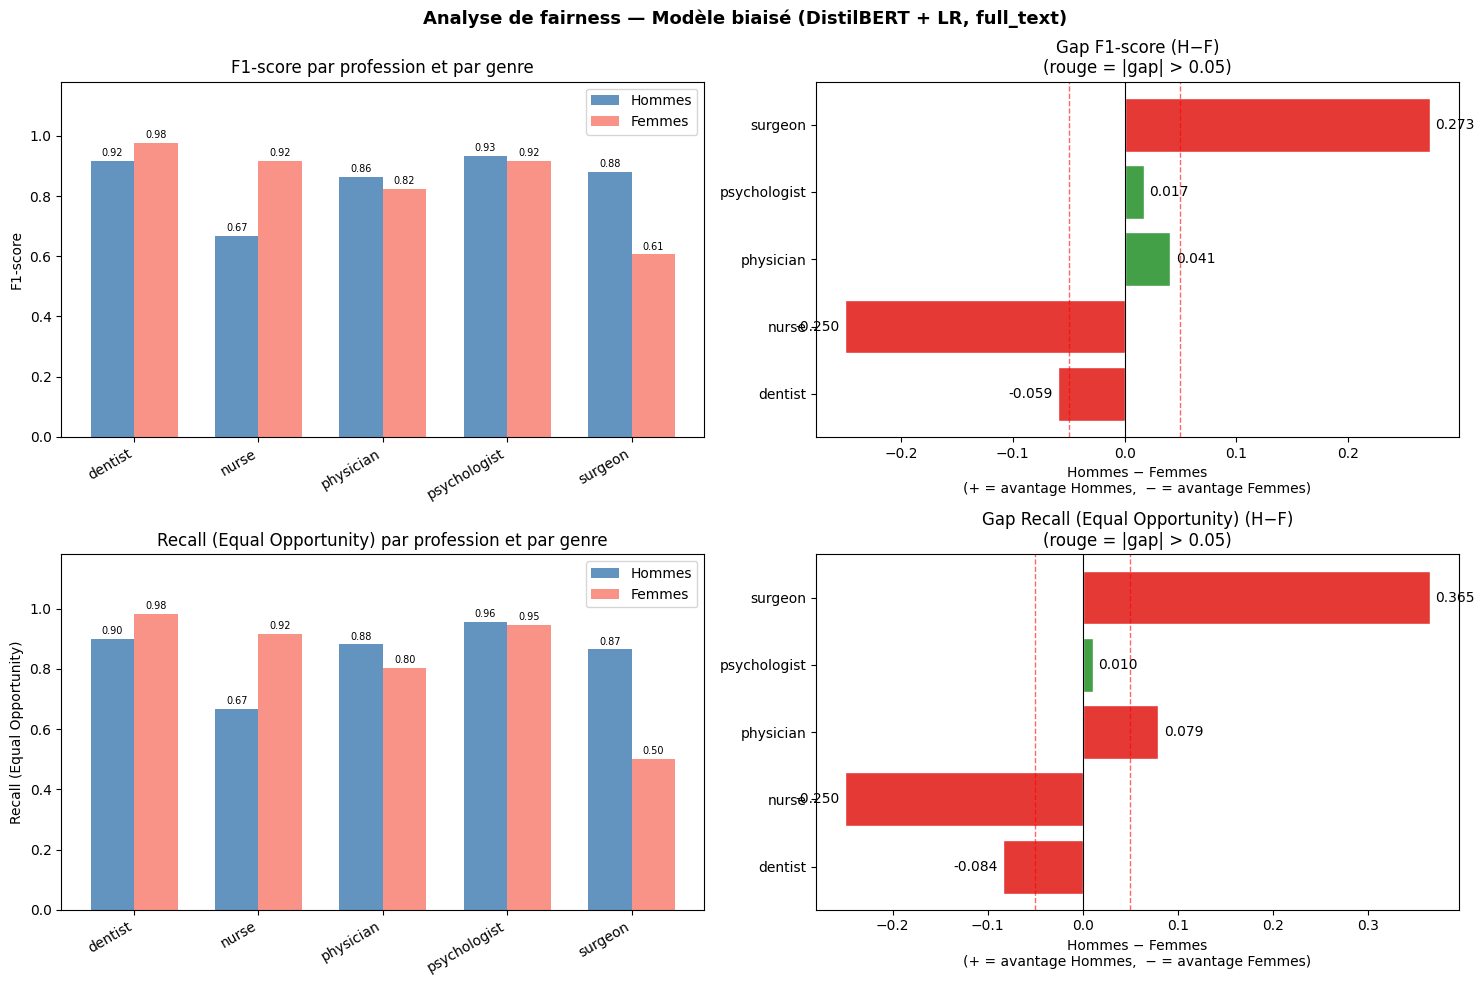

✅ Figure sauvegardée : results_fairness_by_gender.png


In [ ]:
x     = np.arange(N_CLASSES)
width = 0.35

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

plot_cfg = [
    (f1_male,  f1_female,  f1_gap,  "F1-score"),
    (rec_male, rec_female, rec_gap, "Recall (Equal Opportunity)"),
]

for row, (vals_m, vals_f, gap, metric_name) in enumerate(plot_cfg):
    # ── Subplot gauche : barres côte à côte ─────────────────────────
    ax = axes[row][0]
    bars_m = ax.bar(x - width/2, vals_m, width, label="Hommes", color="steelblue", alpha=0.85)
    bars_f = ax.bar(x + width/2, vals_f, width, label="Femmes",  color="salmon",    alpha=0.85)
    ax.bar_label(bars_m, fmt="%.2f", fontsize=7, padding=2)
    ax.bar_label(bars_f, fmt="%.2f", fontsize=7, padding=2)
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
    ax.set_ylim(0, 1.18)
    ax.set_ylabel(metric_name)
    ax.set_title(f"{metric_name} par profession et par genre")
    ax.legend()

    # ── Subplot droit : gap directionnel ────────────────────────────
    ax2 = axes[row][1]
    colors_gap = ["#e53935" if abs(g) > 0.05 else "#43a047" for g in gap]
    bars_gap = ax2.barh(CLASS_NAMES, gap, color=colors_gap, edgecolor="white")
    ax2.bar_label(bars_gap, fmt="%.3f", padding=4)
    ax2.axvline(0,     color="black", linewidth=0.8)
    ax2.axvline( 0.05, color="red", linestyle="--", linewidth=1, alpha=0.6)
    ax2.axvline(-0.05, color="red", linestyle="--", linewidth=1, alpha=0.6)
    ax2.set_xlabel("Hommes − Femmes\n(+ = avantage Hommes,  − = avantage Femmes)")
    ax2.set_title(f"Gap {metric_name} (H−F)\n(rouge = |gap| > 0.05)")

plt.suptitle(
    "Analyse de fairness — Modèle biaisé (DistilBERT + LR, full_text)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("results_fairness_by_gender.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure sauvegardée : results_fairness_by_gender.png")


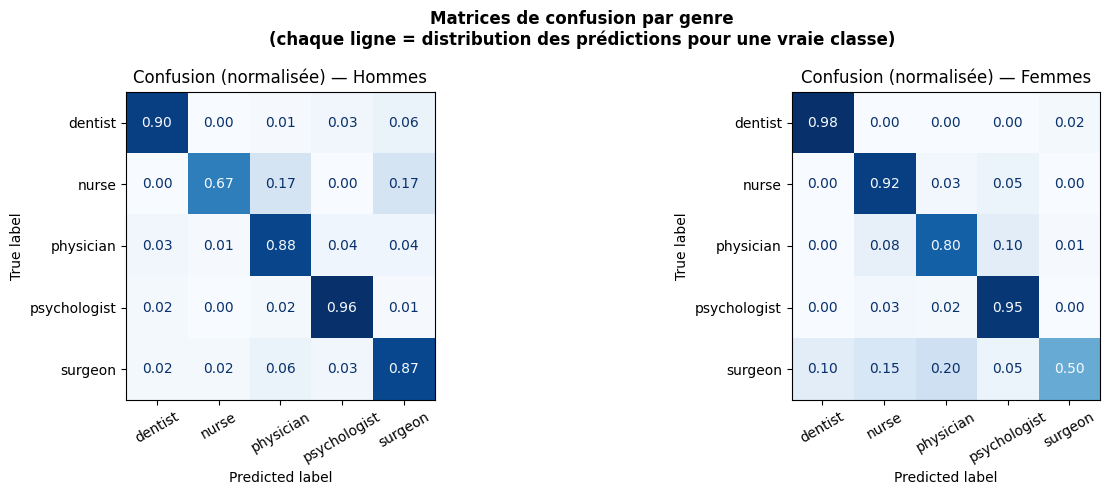

✅ Figure sauvegardée : confusion_matrix_by_gender.png


In [ ]:
# ── Matrices de confusion par genre (normalisées par vraie classe) ────
# Lit les lignes : parmi les X qui SONT chirurgiens, combien sont prédit chirurgien / infirmier / …?
# Un écart entre les deux matrices révèle les confusions systématiques liées au genre.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (gender, label) in zip(axes, [("Male", "Hommes"), ("Female", "Femmes")]):
    mask = val_genders == gender
    cm   = confusion_matrix(y_val[mask], y_pred_val[mask],
                            labels=range(N_CLASSES), normalize="true")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm.round(2), display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format=".2f")
    ax.set_title(f"Confusion (normalisée) — {label}")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle(
    "Matrices de confusion par genre\n"
    "(chaque ligne = distribution des prédictions pour une vraie classe)",
    fontweight="bold"
)
plt.tight_layout()
plt.savefig("confusion_matrix_by_gender.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure sauvegardée : confusion_matrix_by_gender.png")


In [ ]:
# ── Tableau récapitulatif final ──────────────────────────────────────
summary = {
    "Métrique" : ["Accuracy", "F1 macro", "Recall macro (EO)"],
    "Global"   : [acc_val,    f1_macro,   recall_macro],
    "Hommes"   : [gender_stats["Male"]["acc"],
                  gender_stats["Male"]["f1_macro"],
                  gender_stats["Male"]["recall_macro"]],
    "Femmes"   : [gender_stats["Female"]["acc"],
                  gender_stats["Female"]["f1_macro"],
                  gender_stats["Female"]["recall_macro"]],
}
df_summary = pd.DataFrame(summary).set_index("Métrique").round(4)
df_summary["Écart (H−F)"] = (df_summary["Hommes"] - df_summary["Femmes"]).round(4)

print("=" * 65)
print("  TABLEAU RÉCAPITULATIF FINAL")
print("=" * 65)
print(df_summary.to_string())
print()

gap_f1     = gender_stats["Male"]["f1_macro"]     - gender_stats["Female"]["f1_macro"]
gap_recall = gender_stats["Male"]["recall_macro"]  - gender_stats["Female"]["recall_macro"]
print(f"  Gender gap — F1 macro          : {gap_f1:+.4f}")
print(f"  Gender gap — Recall macro (EO) : {gap_recall:+.4f}")
print()
print("→ Étape suivante : réduire le biais en retirant les marqueurs de genre du texte.")


  TABLEAU RÉCAPITULATIF FINAL
                   Global  Hommes  Femmes  Écart (H−F)
Métrique                                              
Accuracy           0.8970  0.8945  0.8989      -0.0044
F1 macro           0.8908  0.8523  0.8479       0.0044
Recall macro (EO)  0.8869  0.8537  0.8295       0.0242

  Gender gap — F1 macro          : +0.0044
  Gender gap — Recall macro (EO) : +0.0242

→ Étape suivante : réduire le biais en retirant les marqueurs de genre du texte.


---
## Section 8 — Preprocessing v2 (débiaisé renforcé) + comparaison v1 / v2

### Stratégie v2 — débiaisage renforcé

| Signal de biais | v1 (biaisé) | **v2 (débiaisé)** |
|---|---|---|
| Pronoms genrés (he/she/him/her) | ❌ conservés | ✅ supprimés |
| Titres genrés (Mr/Mrs/Ms) | ❌ conservés | ✅ supprimés |
| **Prénoms genrés** (John, Sarah…) | ❌ conservés | ✅ **supprimés** |
| Lemmatisation | ❌ aucune | ✅ **avec POS tagging** |
| Stopwords | Manuel (minimaliste) | NLTK complet |

**Nouveautés v2 :**
- **Suppression des prénoms** via le corpus `nltk.corpus.names` : les prénoms sont un signal de genre très fort dans les bios médicales (*"Dr. Sarah"* vs *"Dr. John"*). Les supprimer retire un biais indirect que la v1 ne traitait pas.
- **Lemmatisation POS-aware** : choisit la forme correcte selon le rôle syntaxique du mot (`studies` (nom) → `study`, `running` (verbe) → `run`).


In [ ]:
import nltk
nltk.download("stopwords",                    quiet=True)
nltk.download("wordnet",                      quiet=True)
nltk.download("omw-1.4",                      quiet=True)
nltk.download("names",                        quiet=True)
nltk.download("averaged_perceptron_tagger",   quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)
print("✅ Ressources NLTK téléchargées")


✅ Ressources NLTK téléchargées


In [ ]:
import re
import string
from nltk.corpus import stopwords as nltk_stopwords
from nltk.corpus import names as nltk_names
from nltk import pos_tag
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer

# ── Stopwords NLTK + marqueurs de genre ──────────────────────────────
NLTK_STOPS = set(nltk_stopwords.words("english"))
GENDER_MARKERS = {
    "he", "she", "him", "her", "his", "hers",
    "himself", "herself",
    "mr", "mrs", "ms", "miss", "dr",
}
ALL_STOPS = NLTK_STOPS | GENDER_MARKERS

# ── Mots-labels de profession ─────────────────────────────────────────
LABEL_WORDS_V2 = set()
for cls in CLASS_NAMES:
    for token in re.split(r"[\s\-_/]", cls.lower()):
        if token:
            LABEL_WORDS_V2.add(token)

# ── Prénoms genrés (signal genre indirect) ────────────────────────────
FIRST_NAMES = set(n.lower() for n in nltk_names.words())
print(f"Prénoms chargés : {len(FIRST_NAMES)} entrées")

# ── Helper POS → WordNet ──────────────────────────────────────────────
def _wn_pos(treebank_tag: str) -> str:
    if treebank_tag.startswith("J"):
        return wordnet.ADJ
    elif treebank_tag.startswith("V"):
        return wordnet.VERB
    elif treebank_tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN

_lemmatizer_v2 = WordNetLemmatizer()

def preprocess_v2(text: str) -> str:
    """
    Preprocessing v2 — débiaisé renforcé :
      1. Minuscules
      2. Suppression des URLs et chiffres isolés
      3. Ponctuation → espaces
      4. Filtrage : stopwords NLTK + marqueurs de genre + mots-labels + prénoms
      5. Lemmatisation POS-aware (WordNetLemmatizer + Penn Treebank tags)
      6. Tokens < 2 caractères supprimés
    """
    text = text.lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\b\d+\b", " ", text)
    text = text.translate(str.maketrans(string.punctuation, " " * len(string.punctuation)))

    tokens = [
        t for t in text.split()
        if t not in ALL_STOPS
        and t not in LABEL_WORDS_V2
        and t not in FIRST_NAMES
        and len(t) >= 2
    ]

    if tokens:
        tagged = pos_tag(tokens)
        tokens = [_lemmatizer_v2.lemmatize(w, _wn_pos(tag)) for w, tag in tagged]

    return " ".join(tokens)


# ── Application sur les trois splits ─────────────────────────────────
df_train["text_v2"] = df_train["full_text"].map(preprocess_v2)
df_val["text_v2"]   = df_val["full_text"].map(preprocess_v2)
df_test["text_v2"]  = df_test["full_text"].map(preprocess_v2)

# ── Comparaison v1 vs v2 sur un exemple ──────────────────────────────
idx = 0
print(f"\n--- Texte original ---\n{df_train['full_text'].iloc[idx][:300]}\n")
print(f"--- v1 (biaisé, conserve he/she + prénoms) ---\n{df_train['text_clean'].iloc[idx][:300]}\n")
print(f"--- v2 (débiaisé, supprime he/she + prénoms) ---\n{df_train['text_v2'].iloc[idx][:300]}\n")

avg_v1 = df_train["text_clean"].str.split().str.len().mean()
avg_v2 = df_train["text_v2"].str.split().str.len().mean()
print(f"Longueur moyenne v1 : {avg_v1:.0f} tokens")
print(f"Longueur moyenne v2 : {avg_v2:.0f} tokens  (−{(avg_v1-avg_v2)/avg_v1*100:.1f}% vs v1)")
print(f"\nMarqueurs de genre supprimés : {sorted(GENDER_MARKERS)}")
print(f"Prénoms supprimés (NLTK names) : {len(FIRST_NAMES)}")
print(f"Stopwords totaux : {len(ALL_STOPS)}")


Prénoms chargés : 7576 entrées

--- Texte original ---
Dr. Vikram Prasad is an experienced Dentist in Sowkhya Ayurveda Speciality Clinic, Chennai. He has been a practicing Dentist for 20 years. He has done BDS . He is currently associated with Sree Sai Dental Clinic in Sowkhya Ayurveda Speciality Clinic, Chennai. Book an appointment online with Dr. Vikr

--- v1 (biaisé, conserve he/she + prénoms) ---
dr vikram prasad is an experienced in sowkhya ayurveda speciality clinic chennai he has been a practicing for 20 years he has done bds he is currently associated with sree sai dental clinic in sowkhya ayurveda speciality clinic chennai book an appointment online with dr vikram prasad and consult pri

--- v2 (débiaisé, supprime he/she + prénoms) ---
vikram experience sowkhya ayurveda speciality clinic chennai practice year do bds currently associate sree sai dental clinic sowkhya ayurveda speciality clinic chennai book appointment online vikram consult privately lybrate com

Longueur moyenn

In [ ]:
V2_CACHE = os.path.join(DRIVE_DIR, "embeddings_v2")
os.makedirs(V2_CACHE, exist_ok=True)

v2_train_texts = df_train["text_v2"].tolist()
v2_val_texts   = df_val["text_v2"].tolist()

cache_train_v2 = os.path.join(V2_CACHE, "DistilBERT_X_train.npy")
cache_val_v2   = os.path.join(V2_CACHE, "DistilBERT_X_val.npy")

if os.path.exists(cache_train_v2) and os.path.exists(cache_val_v2):
    print("📂 Chargement des embeddings v2 depuis le cache...")
    X_tr_v2 = np.load(cache_train_v2)
    X_v_v2  = np.load(cache_val_v2)
else:
    print("🔄 Extraction des embeddings train (text_v2)...")
    t0 = time.time()
    X_tr_v2 = extract_embeddings(v2_train_texts, BATCH_SIZE, MAX_LENGTH)
    print("🔄 Extraction des embeddings val (text_v2)...")
    X_v_v2  = extract_embeddings(v2_val_texts,   BATCH_SIZE, MAX_LENGTH)
    print(f"⏱  {time.time()-t0:.0f}s")
    np.save(cache_train_v2, X_tr_v2)
    np.save(cache_val_v2,   X_v_v2)
    print("💾 Embeddings v2 sauvegardés dans", V2_CACHE)

# ── Entraînement LR sur v2 ───────────────────────────────────────────
clf_v2 = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED, n_jobs=-1)
clf_v2.fit(X_tr_v2, y_train)
preds_v2 = clf_v2.predict(X_v_v2)

acc_v2 = accuracy_score(y_val, preds_v2)
f1m_v2 = f1_score(y_val, preds_v2, average="macro")
rem_v2 = recall_score(y_val, preds_v2, average="macro")

per_g_v2 = {}
for g in ["Male", "Female"]:
    mask = val_genders == g
    per_g_v2[g] = {
        "f1_macro"        : f1_score(y_val[mask], preds_v2[mask], average="macro", zero_division=0),
        "recall_macro"    : recall_score(y_val[mask], preds_v2[mask], average="macro", zero_division=0),
        "recall_per_class": recall_score(y_val[mask], preds_v2[mask], average=None,
                                         labels=range(N_CLASSES), zero_division=0),
    }

print(f"\nDistilBERT + v2 — Accuracy={acc_v2:.4f} | F1 macro={f1m_v2:.4f} | Recall macro={rem_v2:.4f}")
for g, label in [("Male","Hommes"), ("Female","Femmes")]:
    print(f"  {label}: F1={per_g_v2[g]['f1_macro']:.4f} | Recall={per_g_v2[g]['recall_macro']:.4f}")
print("✅ DistilBERT v2 terminé!")


📂 Chargement des embeddings v2 depuis le cache...

DistilBERT + v2 — Accuracy=0.8790 | F1 macro=0.8728 | Recall macro=0.8705
  Hommes: F1=0.8236 | Recall=0.8795
  Femmes: F1=0.8561 | Recall=0.8720
✅ DistilBERT v2 terminé!


  COMPARATIF FINAL — DistilBERT + LR  :  v1 (biaisé)  vs  v2 (débiaisé)
                                           F1 macro  Recall macro  Recall (H)  Recall (F)  Gap Recall (H−F)  Gap F1 (H−F)
Preprocessing                                                                                                            
v1 — biaisé (he/she + prénoms conservés)     0.8908        0.8869      0.8537      0.8295            0.0242        0.0044
v2 — débiaisé (genre + prénoms supprimés)    0.8728        0.8705      0.8795      0.8720            0.0075       -0.0326

  ΔGap Recall (v2−v1) : -0.0167  ✅ gap réduit
  ΔGap F1     (v2−v1) : -0.0369  ✅ gap réduit


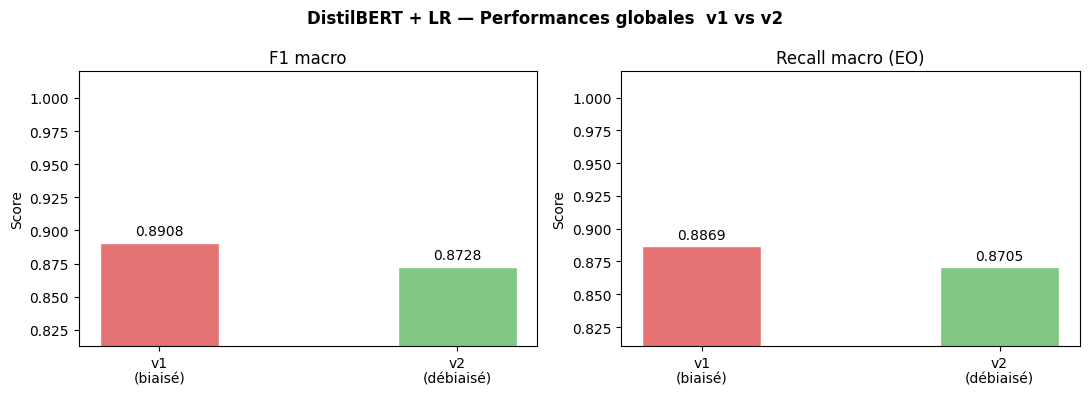

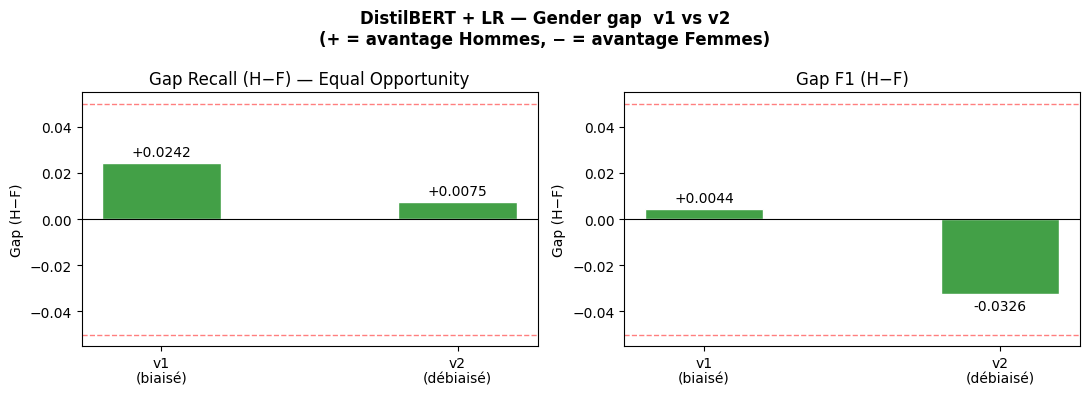

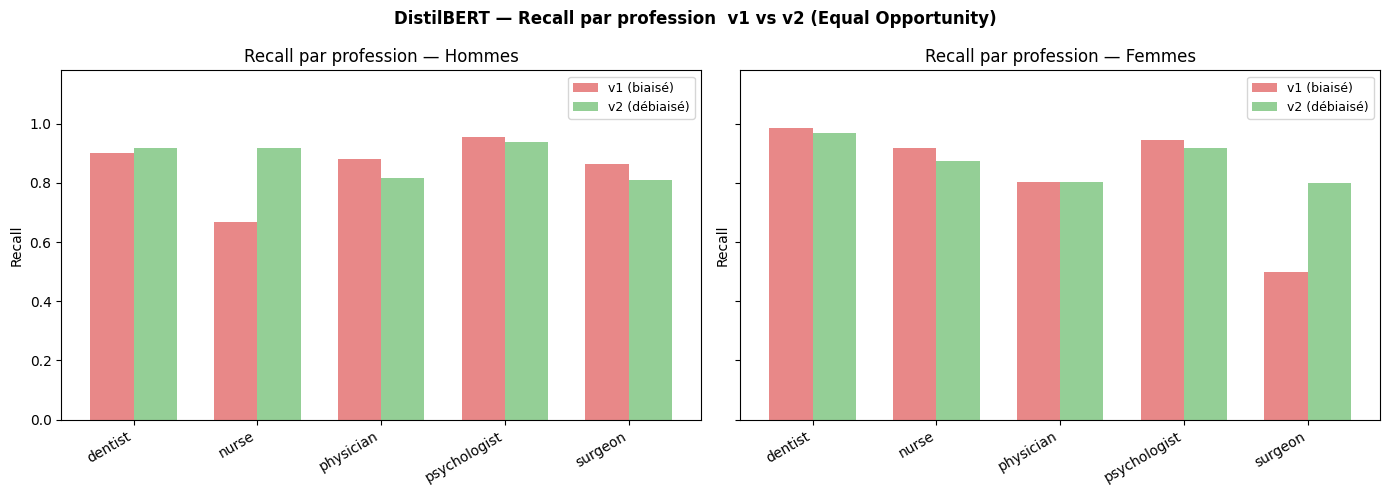

✅ Figures sauvegardées : compare_v2_performance.png, compare_v2_fairness_gap.png, compare_v2_recall_by_profession.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── Résultats v1 (variables déjà calculées aux sections précédentes) ──
gap_rec_v1 = gender_stats["Male"]["recall_macro"]   - gender_stats["Female"]["recall_macro"]
gap_rec_v2 = per_g_v2["Male"]["recall_macro"]        - per_g_v2["Female"]["recall_macro"]
gap_f1_v1  = gender_stats["Male"]["f1_macro"]       - gender_stats["Female"]["f1_macro"]
gap_f1_v2  = per_g_v2["Male"]["f1_macro"]            - per_g_v2["Female"]["f1_macro"]

# ── Table comparative ─────────────────────────────────────────────────
df_v12 = pd.DataFrame([
    {
        "Preprocessing"    : "v1 — biaisé (he/she + prénoms conservés)",
        "F1 macro"         : f1_macro,
        "Recall macro"     : recall_macro,
        "Recall (H)"       : gender_stats["Male"]["recall_macro"],
        "Recall (F)"       : gender_stats["Female"]["recall_macro"],
        "Gap Recall (H−F)" : gap_rec_v1,
        "Gap F1 (H−F)"     : gap_f1_v1,
    },
    {
        "Preprocessing"    : "v2 — débiaisé (genre + prénoms supprimés)",
        "F1 macro"         : f1m_v2,
        "Recall macro"     : rem_v2,
        "Recall (H)"       : per_g_v2["Male"]["recall_macro"],
        "Recall (F)"       : per_g_v2["Female"]["recall_macro"],
        "Gap Recall (H−F)" : gap_rec_v2,
        "Gap F1 (H−F)"     : gap_f1_v2,
    },
]).set_index("Preprocessing").round(4)

print("=" * 85)
print("  COMPARATIF FINAL — DistilBERT + LR  :  v1 (biaisé)  vs  v2 (débiaisé)")
print("=" * 85)
print(df_v12.to_string())
print()
delta_rec = gap_rec_v2 - gap_rec_v1
delta_f1  = gap_f1_v2  - gap_f1_v1
print(f"  ΔGap Recall (v2−v1) : {delta_rec:+.4f}  {'✅ gap réduit' if delta_rec < 0 else '⚠️  gap creusé'}")
print(f"  ΔGap F1     (v2−v1) : {delta_f1:+.4f}  {'✅ gap réduit' if delta_f1 < 0 else '⚠️  gap creusé'}")

# ── Figure 1 : Performances globales ──────────────────────────────────
labels   = ["v1\n(biaisé)", "v2\n(débiaisé)"]
f1_vals  = df_v12["F1 macro"].values
rec_vals = df_v12["Recall macro"].values
colors   = ["#e57373", "#81c784"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (vals, title) in zip(axes, [(f1_vals, "F1 macro"), (rec_vals, "Recall macro (EO)")]):
    bars = ax.bar(labels, vals, color=colors, edgecolor="white", width=0.4)
    ax.bar_label(bars, fmt="%.4f", padding=3)
    ax.set_ylim(max(0, vals.min() - 0.06), 1.02)
    ax.set_title(title)
    ax.set_ylabel("Score")

plt.suptitle("DistilBERT + LR — Performances globales  v1 vs v2", fontweight="bold")
plt.tight_layout()
plt.savefig("compare_v2_performance.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 2 : Gender gap ─────────────────────────────────────────────
gap_rec_vals = df_v12["Gap Recall (H−F)"].values
gap_f1_vals  = df_v12["Gap F1 (H−F)"].values

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (gap_vals, title) in zip(axes, [
    (gap_rec_vals, "Gap Recall (H−F) — Equal Opportunity"),
    (gap_f1_vals,  "Gap F1 (H−F)"),
]):
    bar_c = ["#e53935" if abs(g) > 0.05 else "#43a047" for g in gap_vals]
    bars_gap = ax.bar(labels, gap_vals, color=bar_c, edgecolor="white", width=0.4)
    ax.bar_label(bars_gap, fmt="%+.4f", padding=3)
    ax.axhline(0,     color="black", linewidth=0.8)
    ax.axhline( 0.05, color="red", linestyle="--", linewidth=1, alpha=0.5)
    ax.axhline(-0.05, color="red", linestyle="--", linewidth=1, alpha=0.5)
    ax.set_title(title)
    ax.set_ylabel("Gap (H−F)")

plt.suptitle("DistilBERT + LR — Gender gap  v1 vs v2\n(+ = avantage Hommes, − = avantage Femmes)", fontweight="bold")
plt.tight_layout()
plt.savefig("compare_v2_fairness_gap.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 3 : Recall par profession × genre ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
x = np.arange(N_CLASSES)
w = 0.35
palette  = ["#e57373", "#81c784"]
v_labels = ["v1 (biaisé)", "v2 (débiaisé)"]

rec_sources = [gender_stats, per_g_v2]

for ax, (gender, label) in zip(axes, [("Male", "Hommes"), ("Female", "Femmes")]):
    for i, (src, vlbl) in enumerate(zip(rec_sources, v_labels)):
        vals = src[gender]["recall_per_class"]
        ax.bar(x + (i - 0.5) * w, vals, w, label=vlbl, color=palette[i], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
    ax.set_ylim(0, 1.18)
    ax.set_title(f"Recall par profession — {label}")
    ax.set_ylabel("Recall")
    ax.legend(fontsize=9)

plt.suptitle("DistilBERT — Recall par profession  v1 vs v2 (Equal Opportunity)", fontweight="bold")
plt.tight_layout()
plt.savefig("compare_v2_recall_by_profession.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Figures sauvegardées : compare_v2_performance.png, compare_v2_fairness_gap.png, compare_v2_recall_by_profession.png")


---
### 8.2 — Analyse de fairness par genre (v2 débiaisé)

Même analyse qu'en Section 7, appliquée au modèle v2.  
Objectif : vérifier que la suppression des marqueurs de genre et des prénoms réduit le biais par profession.

  RÉSULTATS PAR GENRE — VALIDATION (v2 débiaisé)

  Hommes (n=436)
    Accuracy     : 0.8739
    F1 macro     : 0.8236
    Recall macro : 0.8795  ← Equal Opportunity

    Profession            F1   Recall
    -------------------------------------
    dentist         : 0.9395   0.9182
    nurse           : 0.5946   0.9167
    physician       : 0.8052   0.8158
    psychologist    : 0.9251   0.9375
    surgeon         : 0.8536   0.8095

  Femmes (n=564)
    Accuracy     : 0.8830
    F1 macro     : 0.8561
    Recall macro : 0.8720  ← Equal Opportunity

    Profession            F1   Recall
    -------------------------------------
    dentist         : 0.9449   0.9677
    nurse           : 0.8922   0.8725
    physician       : 0.8063   0.8021
    psychologist    : 0.9101   0.9176
    surgeon         : 0.7273   0.8000


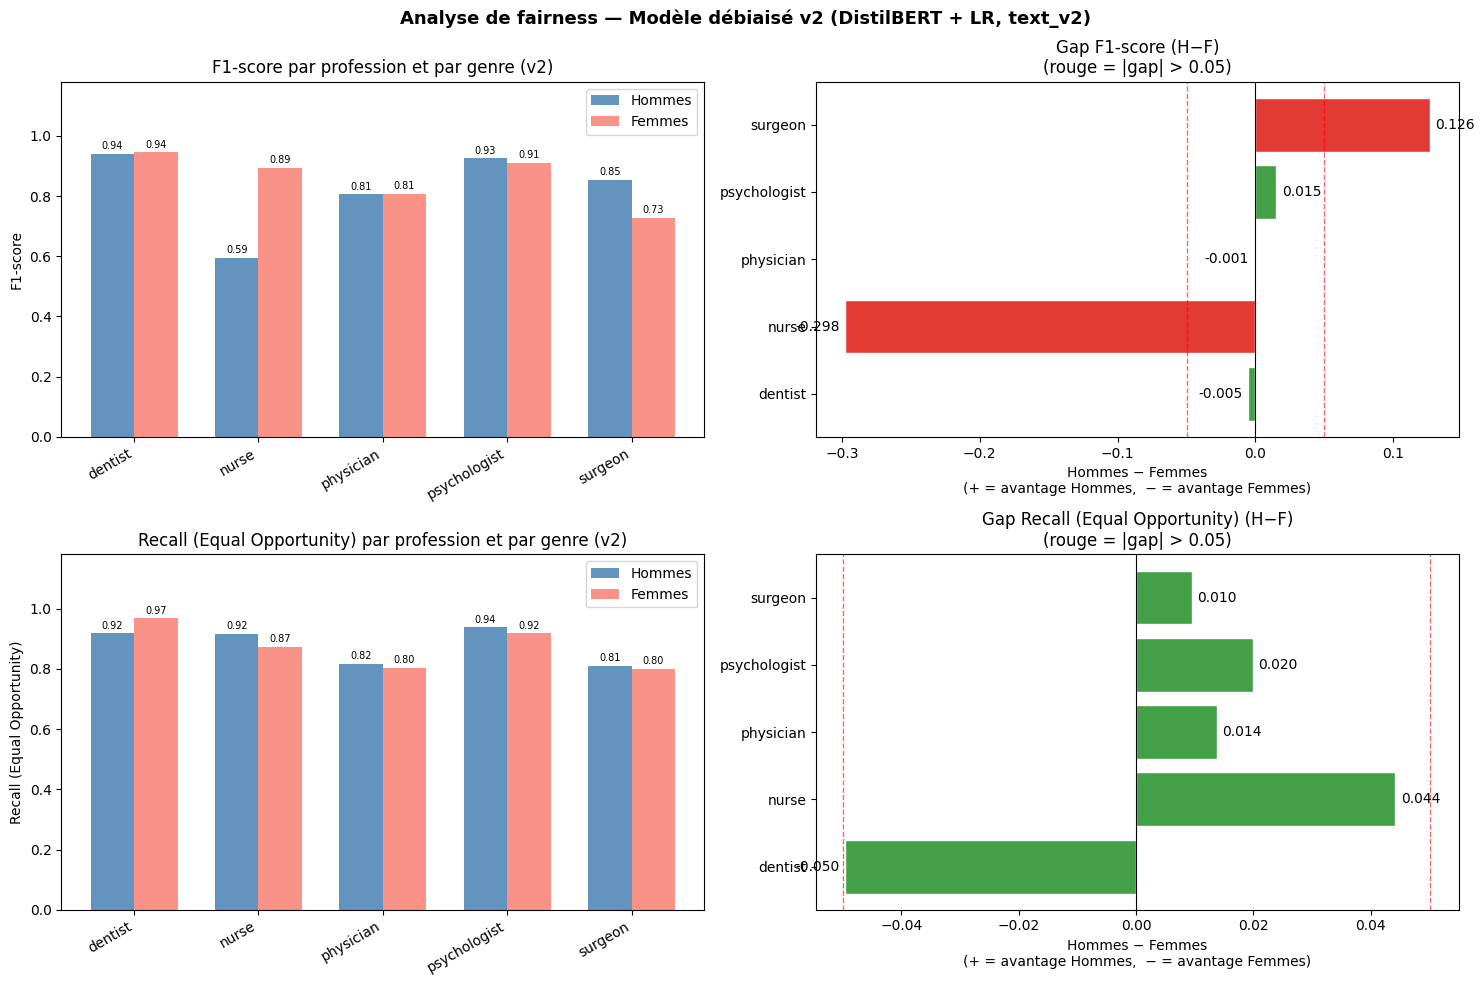

✅ Figure sauvegardée : results_fairness_by_gender_v2.png


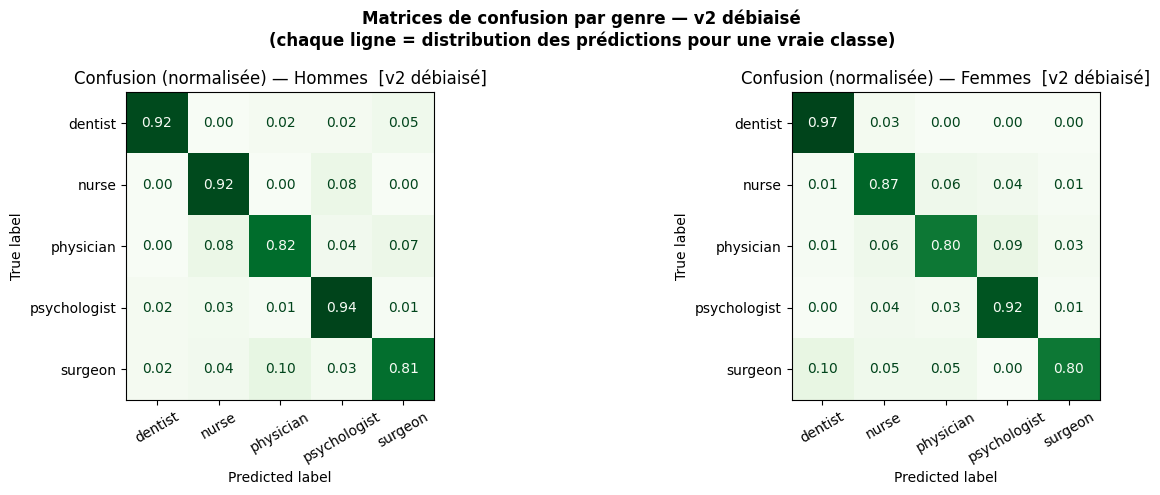

✅ Figure sauvegardée : confusion_matrix_by_gender_v2.png


In [ ]:
# ── Stats par genre pour v2 ──────────────────────────────────────────
gender_stats_v2 = {}

for gender in ["Male", "Female"]:
    mask     = val_genders == gender
    y_true_g = y_val[mask]
    y_pred_g = preds_v2[mask]

    gender_stats_v2[gender] = {
        "n"               : mask.sum(),
        "acc"             : accuracy_score(y_true_g, y_pred_g),
        "f1_macro"        : f1_score(y_true_g, y_pred_g, average="macro",    zero_division=0),
        "recall_macro"    : recall_score(y_true_g, y_pred_g, average="macro", zero_division=0),
        "f1_per_class"    : f1_score(y_true_g, y_pred_g, average=None,
                                     labels=range(N_CLASSES), zero_division=0),
        "recall_per_class": recall_score(y_true_g, y_pred_g, average=None,
                                         labels=range(N_CLASSES), zero_division=0),
    }

print("=" * 65)
print("  RÉSULTATS PAR GENRE — VALIDATION (v2 débiaisé)")
print("=" * 65)
for g, s in gender_stats_v2.items():
    label = "Hommes" if g == "Male" else "Femmes"
    print(f"\n  {label} (n={s['n']})")
    print(f"    Accuracy     : {s['acc']:.4f}")
    print(f"    F1 macro     : {s['f1_macro']:.4f}")
    print(f"    Recall macro : {s['recall_macro']:.4f}  ← Equal Opportunity")
    print(f"\n    {'Profession':<15}   {'F1':>6}   {'Recall':>6}")
    print(f"    {'-'*37}")
    for i, cls in enumerate(CLASS_NAMES):
        print(f"    {cls:<15} : {s['f1_per_class'][i]:>6.4f}   {s['recall_per_class'][i]:>6.4f}")

# ── Gaps directionnels ────────────────────────────────────────────────
f1_m_v2  = gender_stats_v2["Male"]["f1_per_class"]
f1_f_v2  = gender_stats_v2["Female"]["f1_per_class"]
rec_m_v2 = gender_stats_v2["Male"]["recall_per_class"]
rec_f_v2 = gender_stats_v2["Female"]["recall_per_class"]

f1_gap_v2  = f1_m_v2  - f1_f_v2
rec_gap_v2 = rec_m_v2 - rec_f_v2

# ── Figure : F1 et Recall par profession et par genre (v2) ────────────
x     = np.arange(N_CLASSES)
width = 0.35

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

plot_cfg = [
    (f1_m_v2,  f1_f_v2,  f1_gap_v2,  "F1-score"),
    (rec_m_v2, rec_f_v2, rec_gap_v2, "Recall (Equal Opportunity)"),
]

for row, (vals_m, vals_f, gap, metric_name) in enumerate(plot_cfg):
    ax = axes[row][0]
    bars_m = ax.bar(x - width/2, vals_m, width, label="Hommes", color="steelblue", alpha=0.85)
    bars_f = ax.bar(x + width/2, vals_f, width, label="Femmes",  color="salmon",    alpha=0.85)
    ax.bar_label(bars_m, fmt="%.2f", fontsize=7, padding=2)
    ax.bar_label(bars_f, fmt="%.2f", fontsize=7, padding=2)
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
    ax.set_ylim(0, 1.18)
    ax.set_ylabel(metric_name)
    ax.set_title(f"{metric_name} par profession et par genre (v2)")
    ax.legend()

    ax2 = axes[row][1]
    colors_gap = ["#e53935" if abs(g) > 0.05 else "#43a047" for g in gap]
    bars_gap = ax2.barh(CLASS_NAMES, gap, color=colors_gap, edgecolor="white")
    ax2.bar_label(bars_gap, fmt="%.3f", padding=4)
    ax2.axvline(0,     color="black", linewidth=0.8)
    ax2.axvline( 0.05, color="red", linestyle="--", linewidth=1, alpha=0.6)
    ax2.axvline(-0.05, color="red", linestyle="--", linewidth=1, alpha=0.6)
    ax2.set_xlabel("Hommes − Femmes\n(+ = avantage Hommes,  − = avantage Femmes)")
    ax2.set_title(f"Gap {metric_name} (H−F)\n(rouge = |gap| > 0.05)")

plt.suptitle(
    "Analyse de fairness — Modèle débiaisé v2 (DistilBERT + LR, text_v2)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("results_fairness_by_gender_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure sauvegardée : results_fairness_by_gender_v2.png")

# ── Matrices de confusion par genre (v2) ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (gender, label) in zip(axes, [("Male", "Hommes"), ("Female", "Femmes")]):
    mask = val_genders == gender
    cm   = confusion_matrix(y_val[mask], preds_v2[mask],
                            labels=range(N_CLASSES), normalize="true")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm.round(2), display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap="Greens", values_format=".2f")
    ax.set_title(f"Confusion (normalisée) — {label}  [v2 débiaisé]")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle(
    "Matrices de confusion par genre — v2 débiaisé\n"
    "(chaque ligne = distribution des prédictions pour une vraie classe)",
    fontweight="bold"
)
plt.tight_layout()
plt.savefig("confusion_matrix_by_gender_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure sauvegardée : confusion_matrix_by_gender_v2.png")